# 03 — Basic NLP features 

**Research sub-question:** what is the *vocabulary* of the
Hormuz-jet-fuel discourse on each platform, and which terms are
*distinctively* Reddit or YouTube?

**Inputs:** `data/processed/01_preprocessed/{youtube,reddit}_comments.csv`.

**Outputs (`data/processed/02_features/`):**
top n-grams · TF-IDF terms · log-odds distinctive vocabulary · entity /
lexicon counts per platform.

**Methods, in plain terms:**
- N-grams + TF-IDF give the "what is being said" view.
- The log-odds-with-Dirichlet-prior measure (Monroe et al. 2008) handles
  small-corpus rare-term noise more defensibly than raw TF-IDF differences.
- Entity counts use a hand-curated geopolitical phrase list. Lexicon counts
  come from auditable text files under `lexicons/`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA = PROJECT_ROOT / "data"
PROCESSED = DATA / "processed"
RAW = DATA / "raw"
EXTERNAL = PROCESSED / "00_external"
PREPROCESSED = PROCESSED / "01_preprocessed"
FEATURES = PROCESSED / "02_features"
SENTIMENT_TOPICS = PROCESSED / "03_sentiment_topics"
NETWORKS = PROCESSED / "04_networks"
DIFFUSION = PROCESSED / "05_diffusion"
COMPARISON = PROCESSED / "06_comparison"
for d in (EXTERNAL, PREPROCESSED, FEATURES, SENTIMENT_TOPICS, NETWORKS, DIFFUSION, COMPARISON):
    d.mkdir(parents=True, exist_ok=True)
PLOTS = PROJECT_ROOT / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)
LEXICONS = PROJECT_ROOT / "lexicons"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)

## 1 · Feature helpers

In [2]:
"""Inlined NLP helpers: n-grams, TF-IDF, log-odds distinctive terms,
entity / lexicon counting.

Why log-odds with informative Dirichlet prior?
Raw TF-IDF differences across two corpora over-weight rare words and
under-weight robust patterns at small sample sizes. The Monroe, Colaresi &
Quinn (2008) "Fightin' Words" log-odds with a Dirichlet prior estimated
from the pooled corpus gives a z-scored measure that is *defensible at
small N*. The report cites this measure, not raw TF-IDF deltas.
"""

import math
import re
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


GEOPOLITICAL_ENTITIES = {
    "Iran": ["iran", "iranian", "iranians", "tehran", "irgc", "revolutionary guard"],
    "United States": ["united states", "u.s.", "u s", "usa", "america", "american",
                      "americans", "washington", "pentagon", "biden", "trump", "white house"],
    "Israel": ["israel", "israeli", "israelis", "tel aviv", "jerusalem", "idf", "netanyahu"],
    "Saudi Arabia": ["saudi arabia", "saudi", "saudis", "riyadh", "mbs"],
    "UAE": ["uae", "emirates", "abu dhabi", "dubai"],
    "Qatar": ["qatar", "qatari", "doha"],
    "China": ["china", "chinese", "beijing", "ccp"],
    "India": ["india", "indian", "indians", "new delhi", "modi"],
    "Japan": ["japan", "japanese", "tokyo"],
    "Europe / EU": ["europe", "european union", "european", "eu ", " eu,", " eu.", "brussels"],
    "UK": ["united kingdom", "uk ", " uk,", " uk.", "britain", "british", "london"],
    "Russia": ["russia", "russian", "russians", "putin", "kremlin", "moscow"],
    "Middle East": ["middle east", "mideast", "gulf region"],
    "Persian Gulf": ["persian gulf", "arabian gulf"],
    "Strait of Hormuz": ["strait of hormuz", "hormuz strait", "hormuz"],
    "Yemen / Houthis": ["yemen", "houthi", "houthis"],
    "Iraq": ["iraq", "iraqi", "baghdad"],
    "Oman": ["oman", "omani", "muscat"],
}


def load_lexicons(lexicons_dir):
    """Load ``name -> [terms]`` from ``<lexicons_dir>/*.txt``."""
    out = {}
    for path in sorted(lexicons_dir.glob("*.txt")):
        out[path.stem] = [
            ln.strip().lower()
            for ln in path.read_text(encoding="utf-8").splitlines()
            if ln.strip() and not ln.startswith("#")
        ]
    return out


def _compile_phrase_patterns(phrases):
    """Build word-boundary regexes for each phrase (multi-word safe)."""
    pats = []
    for phrase in phrases:
        phrase = phrase.strip()
        if not phrase:
            continue
        if any(ch.isspace() for ch in phrase):
            pat = r"(?<![a-z0-9])" + re.escape(phrase) + r"(?![a-z0-9])"
        else:
            pat = r"\b" + re.escape(phrase) + r"\b"
        pats.append(re.compile(pat, flags=re.IGNORECASE))
    return pats


_ENTITY_PATTERNS = {n: _compile_phrase_patterns(p) for n, p in GEOPOLITICAL_ENTITIES.items()}


def count_entities(text):
    if not isinstance(text, str) or not text:
        return {n: 0 for n in GEOPOLITICAL_ENTITIES}
    lower = text.lower()
    return {n: sum(len(p.findall(lower)) for p in pats)
            for n, pats in _ENTITY_PATTERNS.items()}


def add_entity_columns(df, text_col="clean_text"):
    if df.empty: return df
    mat = df[text_col].fillna("").apply(count_entities).apply(pd.Series).add_prefix("entity_")
    return pd.concat([df.reset_index(drop=True), mat.reset_index(drop=True)], axis=1)


def add_lexicon_columns(df, lex, text_col="clean_text"):
    if df.empty: return df
    pats = {n: _compile_phrase_patterns(terms) for n, terms in lex.items()}
    def row(text):
        lower = text.lower() if isinstance(text, str) else ""
        return {n: sum(len(p.findall(lower)) for p in ps) for n, ps in pats.items()}
    mat = df[text_col].fillna("").apply(row).apply(pd.Series).add_prefix("lex_")
    return pd.concat([df.reset_index(drop=True), mat.reset_index(drop=True)], axis=1)


def top_ngrams(texts, ngram_range=(1, 1), top_k=40, min_df=2):
    docs = [t for t in texts if isinstance(t, str) and t.strip()]
    if not docs:
        return pd.DataFrame(columns=["term", "count", "doc_freq"])
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df,
                          token_pattern=r"(?u)\b[a-z][a-z\-']{2,}\b")
    X = vec.fit_transform(docs)
    df = pd.DataFrame({
        "term": vec.get_feature_names_out(),
        "count": np.asarray(X.sum(axis=0)).ravel(),
        "doc_freq": np.asarray((X > 0).sum(axis=0)).ravel(),
    })
    return df.sort_values("count", ascending=False).head(top_k).reset_index(drop=True)


def tfidf_top_terms(texts, top_k=40, ngram_range=(1, 2), min_df=3):
    docs = [t for t in texts if isinstance(t, str) and t.strip()]
    if not docs:
        return pd.DataFrame(columns=["term", "tfidf"])
    vec = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df,
                          token_pattern=r"(?u)\b[a-z][a-z\-']{2,}\b")
    X = vec.fit_transform(docs)
    df = pd.DataFrame({"term": vec.get_feature_names_out(),
                       "tfidf": np.asarray(X.mean(axis=0)).ravel()})
    return df.sort_values("tfidf", ascending=False).head(top_k).reset_index(drop=True)


def log_odds_distinctive(texts_a, texts_b, top_k=25, min_count=5, ngram_range=(1, 2)):
    """Monroe et al. (2008) log-odds with informative Dirichlet prior."""
    docs_a = [t for t in texts_a if isinstance(t, str) and t.strip()]
    docs_b = [t for t in texts_b if isinstance(t, str) and t.strip()]
    if not docs_a or not docs_b:
        return pd.DataFrame()
    vec = CountVectorizer(ngram_range=ngram_range, min_df=1,
                          token_pattern=r"(?u)\b[a-z][a-z\-']{2,}\b")
    vec.fit(docs_a + docs_b)
    A = np.asarray(vec.transform(docs_a).sum(axis=0)).ravel().astype(float)
    B = np.asarray(vec.transform(docs_b).sum(axis=0)).ravel().astype(float)
    prior = A + B
    keep = prior >= min_count
    A, B, prior = A[keep], B[keep], prior[keep]
    terms = np.array(vec.get_feature_names_out())[keep]
    n_a, n_b, n_w = A.sum(), B.sum(), prior.sum()
    odds_a = (A + prior) / (n_a + n_w - A - prior)
    odds_b = (B + prior) / (n_b + n_w - B - prior)
    delta = np.log(odds_a) - np.log(odds_b)
    var = 1.0 / (A + prior) + 1.0 / (B + prior)
    z = delta / np.sqrt(var)
    df = pd.DataFrame({"term": terms, "count_a": A.astype(int), "count_b": B.astype(int),
                       "log_odds": delta, "z_score": z})
    top_a = df.nlargest(top_k, "z_score").assign(direction="A")
    top_b = df.nsmallest(top_k, "z_score").assign(direction="B")
    return pd.concat([top_a, top_b], ignore_index=True)

## 2 · Load the analysis corpus

In [3]:
def load_corpus(preprocessed_dir):
    """Load + stack both platforms' English non-deleted comments."""
    frames = []
    for stem in ("youtube_comments", "reddit_comments"):
        p = preprocessed_dir / f"{stem}.parquet"
        c = preprocessed_dir / f"{stem}.csv"
        if p.exists(): frames.append(pd.read_parquet(p))
        elif c.exists(): frames.append(pd.read_csv(c))
    df = pd.concat(frames, ignore_index=True, sort=False)
    if "language" in df.columns:
        df = df[df["language"] == "en"].copy()
    if "is_empty_or_deleted" in df.columns:
        df = df[~df["is_empty_or_deleted"].fillna(False)].copy()
    df["lemma_text"] = df["lemma_text"].fillna("")
    df["clean_text"] = df["clean_text"].fillna("")
    return df


corpus = load_corpus(PREPROCESSED)

# Corpus summary for the report: n comments, vocabulary size, type-token ratio.
summary = []
for platform in sorted(corpus["platform"].unique()):
    sub = corpus[corpus["platform"] == platform]
    toks = sub["lemma_text"].str.split().explode()
    summary.append({
        "platform": platform,
        "comments": int(len(sub)),
        "tokens": int(toks.notna().sum()),
        "unique_terms": int(toks.dropna().nunique()),
        "type_token_ratio": round(toks.dropna().nunique() / max(toks.notna().sum(), 1), 4),
    })
print(pd.DataFrame(summary).to_string(index=False))


platform  comments  tokens  unique_terms  type_token_ratio
  reddit     17162  237196         18995            0.0801
 youtube     26136  296975         27293            0.0919


## 3 · Top n-grams per platform

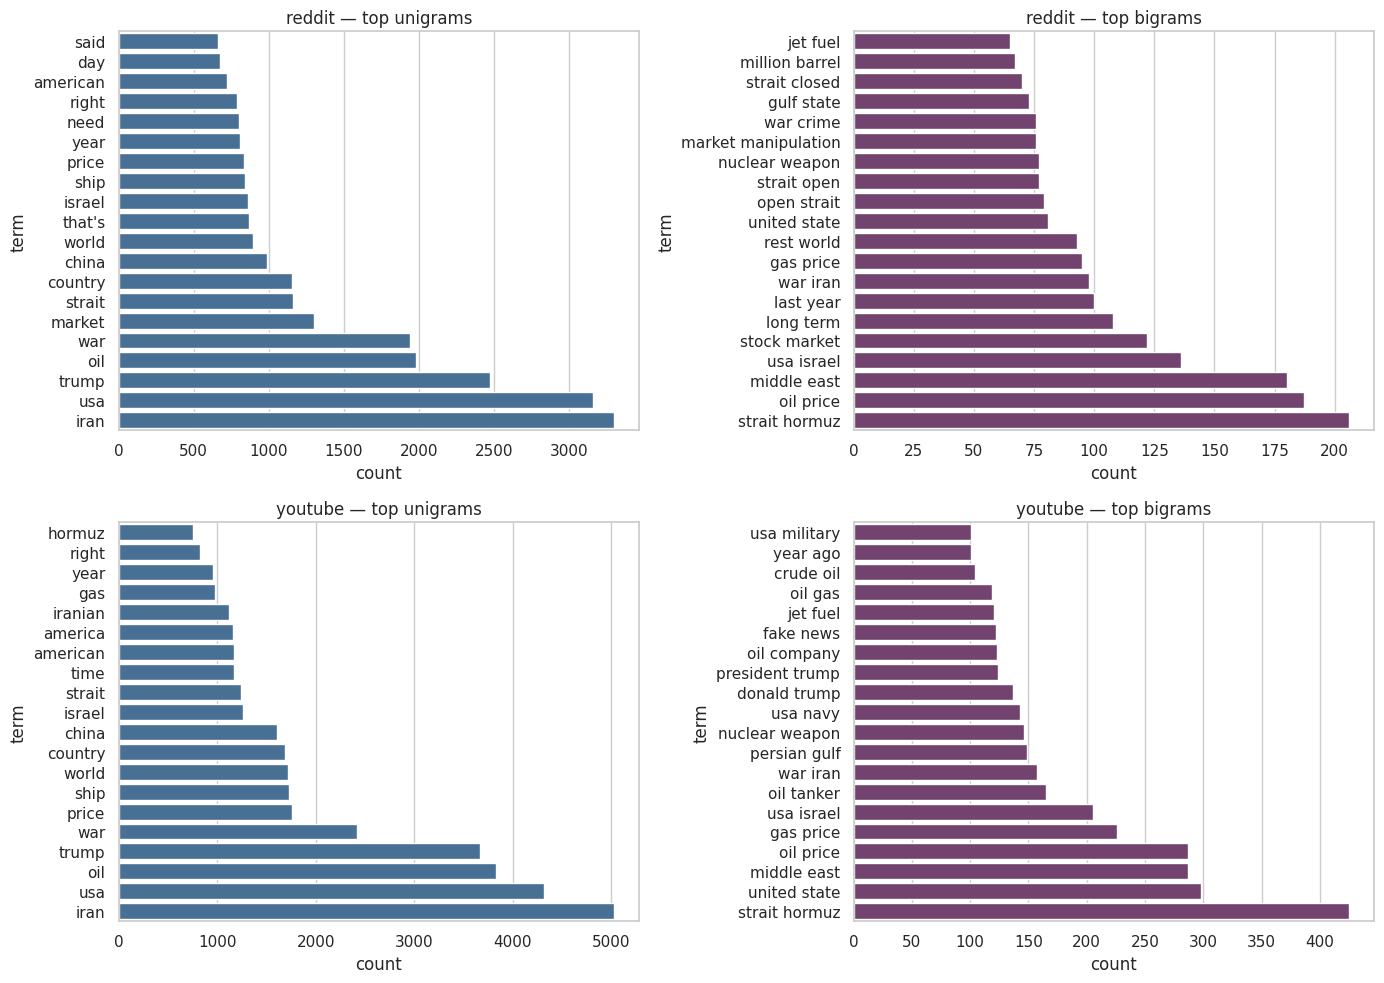

In [4]:
ngram_tables = {}
for platform in ("reddit", "youtube"):
    sub = corpus[corpus["platform"] == platform]["lemma_text"]
    for n in (1, 2, 3):
        df = top_ngrams(sub, ngram_range=(n, n), top_k=40)
        df.to_csv(FEATURES / f"top_{n}grams_{platform}.csv", index=False)
        ngram_tables[(platform, n)] = df

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, platform in enumerate(["reddit", "youtube"]):
    sns.barplot(data=ngram_tables[(platform, 1)].head(20).iloc[::-1],
                y="term", x="count", ax=axes[i, 0], color="#3b6fa1")
    axes[i, 0].set_title(f"{platform} — top unigrams")
    sns.barplot(data=ngram_tables[(platform, 2)].head(20).iloc[::-1],
                y="term", x="count", ax=axes[i, 1], color="#7a3b75")
    axes[i, 1].set_title(f"{platform} — top bigrams")
plt.tight_layout()
plt.show()

**Read:** vocabulary on both platforms clusters on the expected Hormuz/Iran/oil core. Reddit bigrams skew toward market and shipping mechanics (`oil price`, `strait of`); YouTube bigrams skew toward broader geopolitical framing.

## 4 · TF-IDF top terms per platform

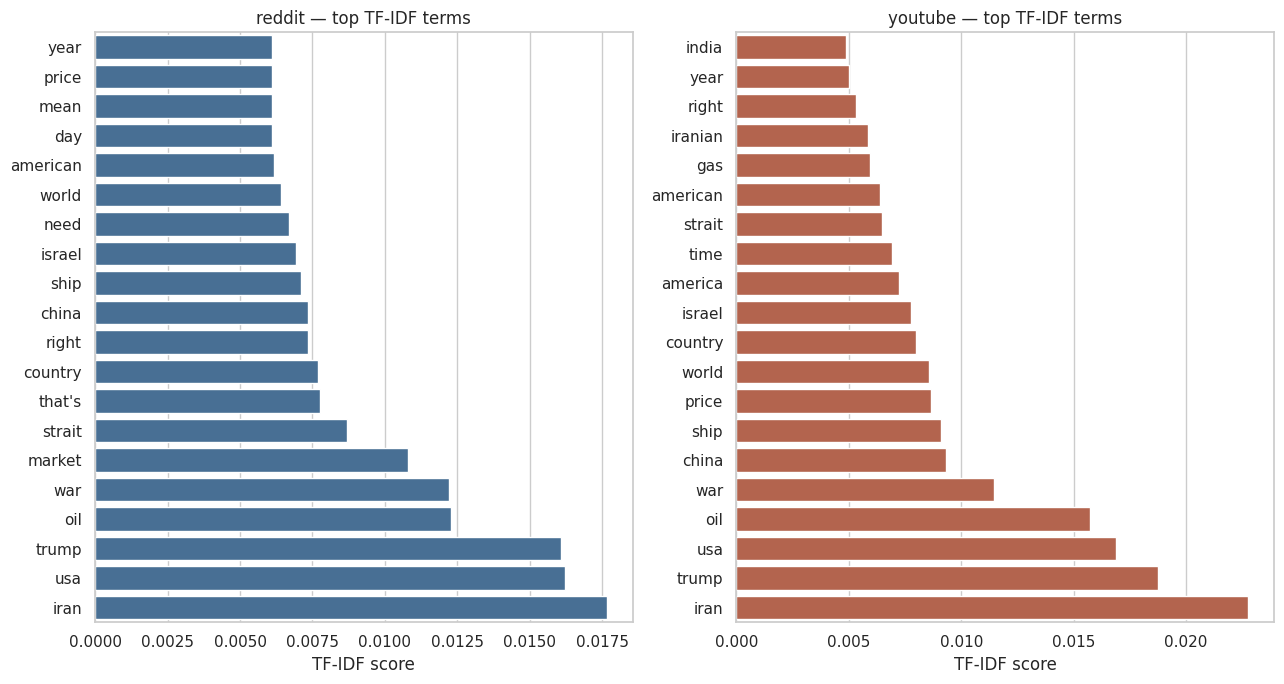

In [5]:
tfidf_tables = {}
for platform in ("reddit", "youtube"):
    sub = corpus[corpus["platform"] == platform]["lemma_text"]
    df = tfidf_top_terms(sub, top_k=40)
    df.to_csv(FEATURES / f"tfidf_top_terms_{platform}.csv", index=False)
    tfidf_tables[platform] = df

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharex=False)
for ax, platform in zip(axes, ("reddit", "youtube")):
    sns.barplot(
        data=tfidf_tables[platform].head(20).iloc[::-1],
        y="term", x="tfidf", ax=ax,
        color="#3b6fa1" if platform == "reddit" else "#c45a3d",
    )
    ax.set_title(f"{platform} — top TF-IDF terms")
    ax.set_xlabel("TF-IDF score")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PLOTS / "tfidf_top_terms.png", dpi=160, bbox_inches="tight")
plt.show()


## 5 · Platform-distinctive vocabulary (log-odds, Monroe 2008)

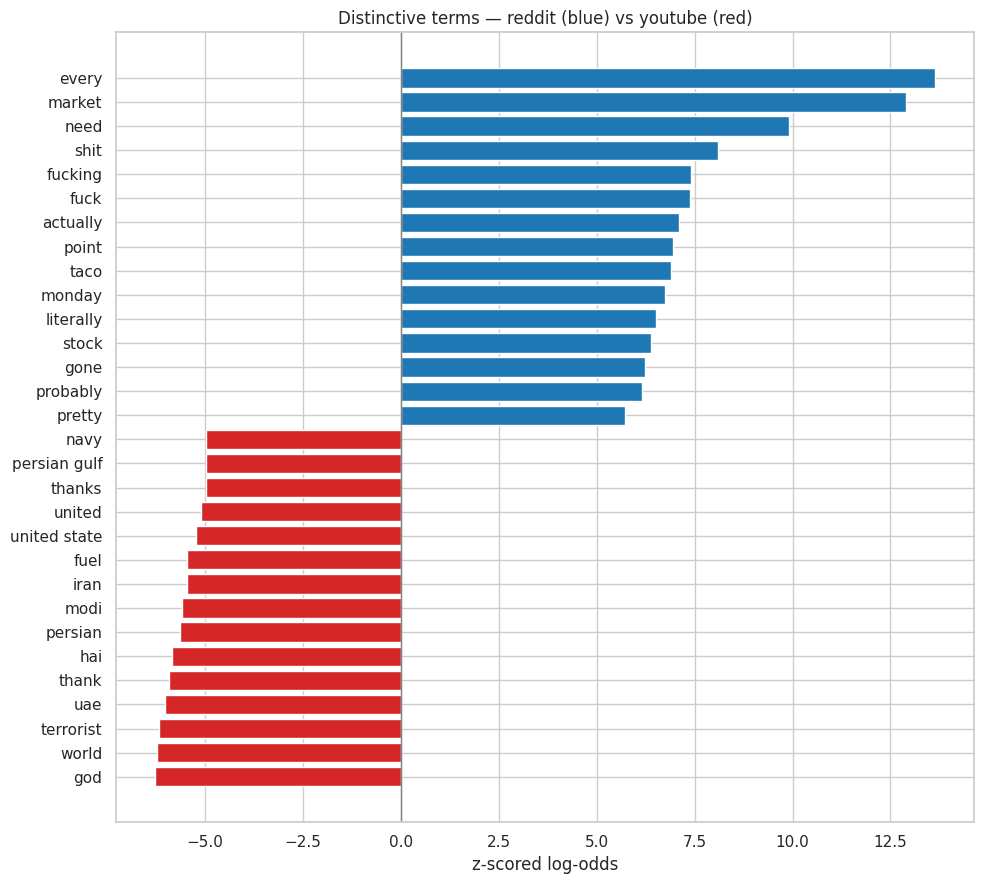

,term,count_reddit,count_youtube,log_odds,z_score,direction
35,god,98,391,-0.334719,-6.280961,youtube
36,world,897,1723,-0.141138,-6.221764,youtube
37,terrorist,96,380,-0.332945,-6.165141,youtube
38,uae,113,406,-0.310723,-6.020858,youtube
39,thank,80,333,-0.344002,-5.926765,youtube
40,hai,0,132,-0.622827,-5.842632,youtube
41,persian,25,194,-0.455991,-5.647335,youtube
42,modi,0,121,-0.622815,-5.593792,youtube
43,iran,3300,5032,-0.069347,-5.468743,youtube
44,fuel,251,623,-0.215547,-5.462766,youtube


In [6]:
platforms = sorted(corpus["platform"].unique())
a, b = platforms[0], platforms[1]
dist = log_odds_distinctive(
    corpus.loc[corpus["platform"] == a, "lemma_text"],
    corpus.loc[corpus["platform"] == b, "lemma_text"],
    top_k=25,
).rename(columns={"count_a": f"count_{a}", "count_b": f"count_{b}"})
dist["direction"] = dist["direction"].map({"A": a, "B": b})
dist.to_csv(FEATURES / f"distinctive_terms_{a}_vs_{b}.csv", index=False)

top = pd.concat([dist.head(15), dist.tail(15)]).sort_values("z_score")
plt.figure(figsize=(10, 9))
colors = ["#d62728" if z < 0 else "#1f77b4" for z in top["z_score"]]
plt.barh(top["term"], top["z_score"], color=colors)
plt.axvline(0, color="grey", linewidth=1)
plt.title(f"Distinctive terms — {a} (blue) vs {b} (red)")
plt.xlabel("z-scored log-odds")
plt.tight_layout()
plt.savefig(PLOTS / "distinctive_terms.png", dpi=160, bbox_inches="tight")
plt.show()
top

**Read:** Reddit-distinctive terms cluster around concrete market mechanics, brokerage, and trade vocabulary; YouTube-distinctive terms cluster around address-the-viewer phrases ("watch", "video", "channel") plus broader emotional / religious framing. This is consistent with the structural difference between a discussion platform (Reddit) and a broadcast platform (YouTube).

## 6 · Per-subreddit Reddit distinctive vocabulary

The platform-level log-odds in §5 averages
across eight subreddits with very different registers (r/wallstreetbets
vs r/Economics is a register chasm).  This section computes log-odds
for each subreddit against the rest of Reddit, so the report can quote
what each community *adds* to the Reddit aggregate.


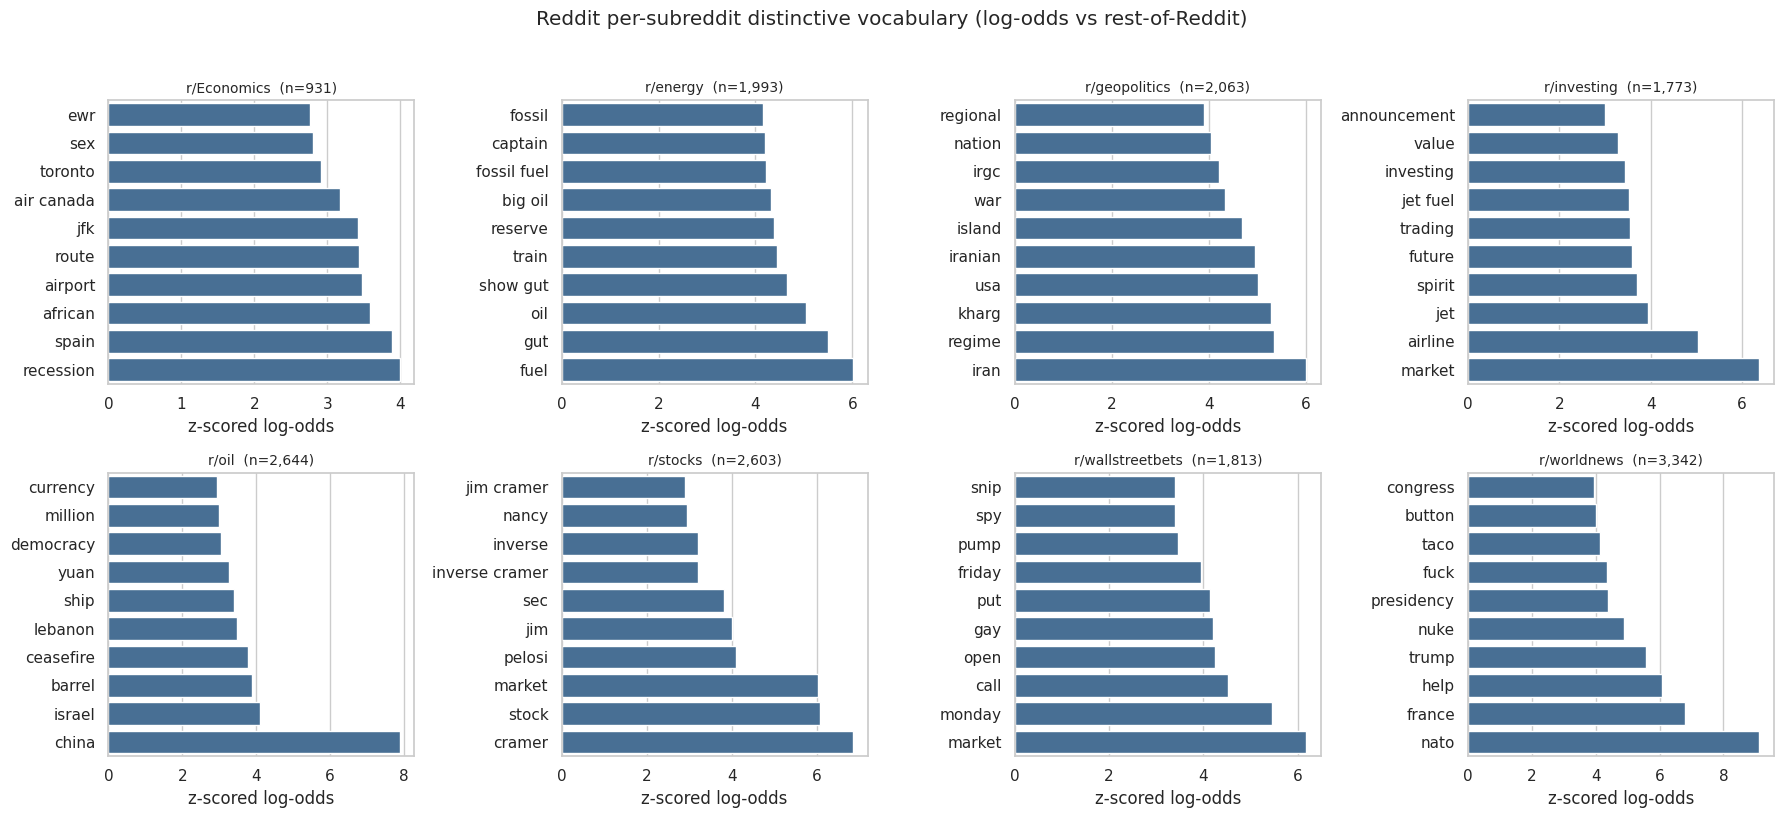

In [7]:
reddit_only = corpus[corpus["platform"] == "reddit"]
subs = sorted(reddit_only["subreddit"].dropna().unique())
sub_distinctive = {}
for sub in subs:
    a_docs = reddit_only.loc[reddit_only["subreddit"] == sub, "lemma_text"]
    b_docs = reddit_only.loc[reddit_only["subreddit"] != sub, "lemma_text"]
    if len(a_docs) < 50 or len(b_docs) < 50:
        continue
    df = log_odds_distinctive(a_docs, b_docs, top_k=12)
    sub_distinctive[sub] = df

flat = []
for sub, df in sub_distinctive.items():
    for _, r in df.iterrows():
        flat.append({
            "subreddit": sub, "term": r["term"], "z_score": float(r["z_score"]),
            "count_in_sub": int(r["count_a"]), "count_in_rest": int(r["count_b"]),
        })
pd.DataFrame(flat).to_csv(FEATURES / "subreddit_distinctive_terms.csv", index=False)

n = len(sub_distinctive)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=False)
for ax, (sub, df) in zip(axes.flat, sub_distinctive.items()):
    top = df.sort_values("z_score", ascending=False).head(10).iloc[::-1]
    sns.barplot(data=top, y="term", x="z_score", ax=ax, color="#3b6fa1")
    ax.set_title(f"r/{sub}  (n={len(reddit_only[reddit_only['subreddit']==sub]):,})", fontsize=10)
    ax.set_xlabel("z-scored log-odds")
    ax.set_ylabel("")
for ax in axes.flat[len(sub_distinctive):]:
    ax.axis("off")
plt.suptitle("Reddit per-subreddit distinctive vocabulary (log-odds vs rest-of-Reddit)", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS / "subreddit_distinctive_terms.png", dpi=160, bbox_inches="tight")
plt.show()


**Read:** each subreddit contributes its own framing flavour — finance
subs surface trade-jargon, news subs surface geopolitical actors, oil
sub surfaces market-mechanics.  The report quotes the top-3 from each
sub as a sampling-frame audit.


## 7 · Geopolitical entity mention rates

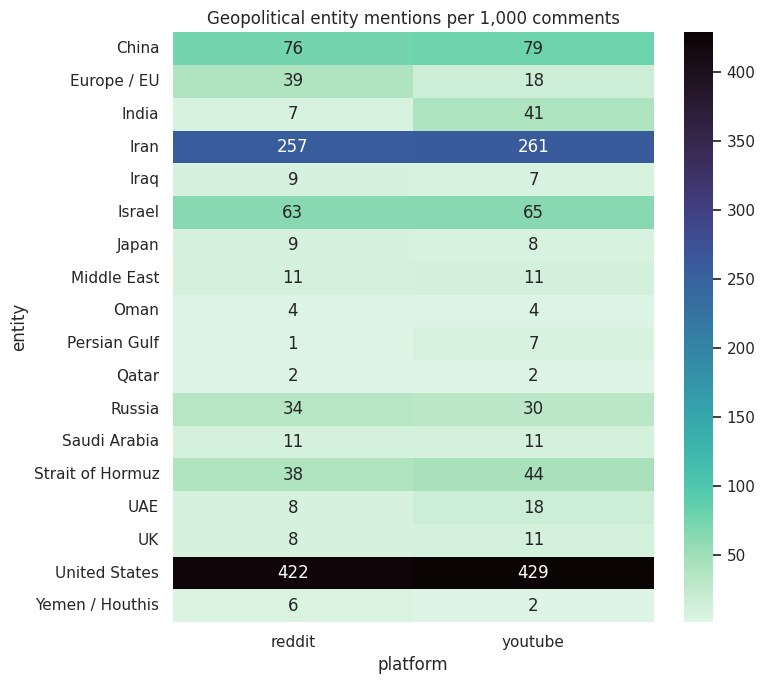

In [8]:
enriched = add_lexicon_columns(add_entity_columns(corpus), load_lexicons(LEXICONS))
entity_cols = [c for c in enriched.columns if c.startswith("entity_")]
lex_cols = [c for c in enriched.columns if c.startswith("lex_")]

# Per-platform totals + per-comment rates
summary_rows = []
for platform in sorted(corpus["platform"].unique()):
    sub = enriched[enriched["platform"] == platform]
    row = {"platform": platform, "comments": int(len(sub))}
    for col in entity_cols + lex_cols:
        row[f"{col}_total"] = int(sub[col].sum())
        row[f"{col}_rate_per_comment"] = float(sub[col].mean()) if len(sub) else 0.0
    summary_rows.append(row)
pd.DataFrame(summary_rows).to_csv(FEATURES / "entity_lexicon_summary.csv", index=False)

# Long-form for the heatmap
long_rows = []
for platform in sorted(corpus["platform"].unique()):
    sub = enriched[enriched["platform"] == platform]
    for col in entity_cols:
        long_rows.append({
            "platform": platform,
            "entity": col.replace("entity_", ""),
            "mentions_per_1k_comments": (sub[col].sum() / max(len(sub), 1)) * 1000.0,
        })
ent_long = pd.DataFrame(long_rows)
ent_long.to_csv(FEATURES / "entity_mentions_long.csv", index=False)

pivot = ent_long.pivot(index="entity", columns="platform", values="mentions_per_1k_comments").fillna(0)
plt.figure(figsize=(8, 7))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="mako_r")
plt.title("Geopolitical entity mentions per 1,000 comments")
plt.tight_layout()
plt.savefig(PLOTS / "entity_mention_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

**Read:** Iran, the United States, and Israel dominate on both platforms. Reddit mentions regional actors (UAE, Qatar, Yemen/Houthis) and trade partners (China, India) far more often than YouTube does — consistent with Reddit's market-mechanics framing vs. YouTube's superpower-rivalry framing.

## 8 · Topical-frame match rates (lexicon-based)

The seven hand-curated lexicons in `lexicons/` capture the *frames*
communities use to make sense of the crisis: oil-supply, market
speculation, jet-fuel/aviation, shipping/tanker, geopolitics/security,
uncertainty/fear, and religion/philosophy/ethics. We count the
fraction of comments per platform that contain at least one match
from each lexicon. This is a coarse-but-defensible measure of which
framing each community leans on.


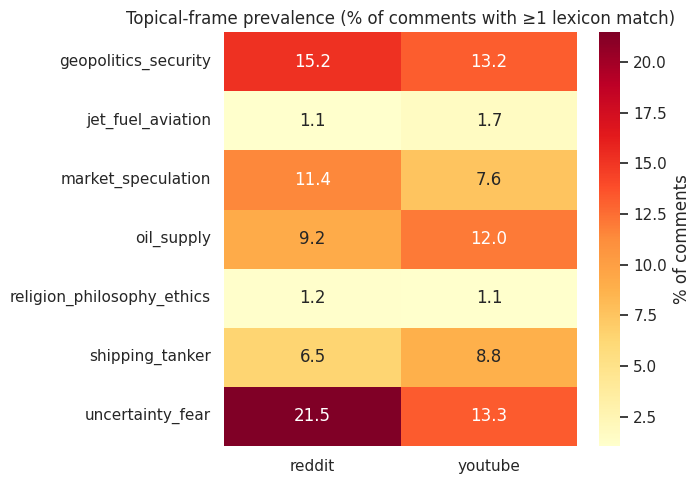

,platform,comments,lex_geopolitics_security_pct_comments,lex_geopolitics_security_per_1k,lex_jet_fuel_aviation_pct_comments,lex_jet_fuel_aviation_per_1k,lex_market_speculation_pct_comments,lex_market_speculation_per_1k,lex_oil_supply_pct_comments,lex_oil_supply_per_1k,lex_religion_philosophy_ethics_pct_comments,lex_religion_philosophy_ethics_per_1k,lex_shipping_tanker_pct_comments,lex_shipping_tanker_per_1k,lex_uncertainty_fear_pct_comments,lex_uncertainty_fear_per_1k
0,reddit,17162,15.184710,232.140776,1.101270,14.800140,11.432234,174.455192,9.200559,162.801538,1.177019,14.333994,6.467778,97.482811,21.454376,313.949423
1,youtube,26136,13.177227,182.009489,1.702632,22.191613,7.575758,114.554637,11.983471,215.679522,1.067493,14.654117,8.819253,129.323538,13.322620,182.698194


In [9]:
lex_summary_rows = []
for platform in sorted(enriched["platform"].unique()):
    sub = enriched[enriched["platform"] == platform]
    n = max(len(sub), 1)
    row = {"platform": platform, "comments": int(len(sub))}
    for col in lex_cols:
        # Two metrics:
        # 1. % of comments with >= 1 match (frame *prevalence*)
        # 2. matches per 1,000 comments (frame *intensity*)
        row[f"{col}_pct_comments"] = float((sub[col] > 0).mean() * 100.0)
        row[f"{col}_per_1k"] = float(sub[col].sum() / n * 1000.0)
    lex_summary_rows.append(row)
lex_summary = pd.DataFrame(lex_summary_rows)
lex_summary.to_csv(FEATURES / "lexicon_match_rates.csv", index=False)

# Long-form for plotting
plot_rows = []
for platform in sorted(enriched["platform"].unique()):
    sub = enriched[enriched["platform"] == platform]
    n = max(len(sub), 1)
    for col in lex_cols:
        plot_rows.append({
            "platform": platform,
            "lexicon": col.replace("lex_", ""),
            "pct_comments": float((sub[col] > 0).mean() * 100.0),
        })
lex_long = pd.DataFrame(plot_rows)

pivot = lex_long.pivot(index="lexicon", columns="platform", values="pct_comments").fillna(0)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "% of comments"})
ax.set_title("Topical-frame prevalence (% of comments with ≥1 lexicon match)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PLOTS / "lexicon_frame_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()
lex_summary


**Read:** the heatmap reveals which *frame* each community leans on.
If Reddit shows a higher share of `market_speculation` matches and
YouTube a higher share of `geopolitics_security`, that is direct
evidence for the framing-difference claim that the report's RQ asks
us to test. `jet_fuel_aviation` is the prevalence of the explicit
jet-fuel frame — the topic that motivated the study.


## Generated artifacts

Relevant existing outputs from this notebook are:

- `data/processed/02_features/top_1grams_reddit.csv`, `top_2grams_reddit.csv`, `top_3grams_reddit.csv`
- `data/processed/02_features/top_1grams_youtube.csv`, `top_2grams_youtube.csv`, `top_3grams_youtube.csv`
- `data/processed/02_features/tfidf_top_terms_reddit.csv`, `tfidf_top_terms_youtube.csv`
- `data/processed/02_features/distinctive_terms_reddit_vs_youtube.csv`
- `data/processed/02_features/subreddit_distinctive_terms.csv`
- `data/processed/02_features/entity_lexicon_summary.csv`
- `data/processed/02_features/lexicon_match_rates.csv`

## Report-ready findings

- The corpus contains **17,162 Reddit** and **26,136 YouTube** English, deduplicated comments.
- The dominant vocabulary is Hormuz/Iran/oil/security language rather than explicit downstream aviation language. The lexicon audit finds `jet_fuel_aviation` framing is rare: **1.1% of Reddit** and **1.7% of YouTube** comments.
- Both platforms share the core crisis vocabulary, but Reddit contributes more market-mechanics and investment register, while YouTube contributes broader geopolitical and actor-centred language.
- Use this notebook as lexical framing support. The graded headline claims come from notebooks 04, 05, 06, 07, and 08.
